#PCA

El análisis de componentes principales (PCA) es un método estadistico lineal utilizado para la reducción de dimensión. Su objetivo es transformar un conjunto de variables posiblemente correlacionadas en un conjunto de variables no correlacionadas llamadas **componentes principales**, que son combinaciones lineales de las variables originales.

## Preprocesamiento de datos

Para el preprocesamiento de los datos de audio, primero se cargaron los primeros 5 segundos de dos archivos de audio *mi_perro_dinamita.mp3* y *exclusive.mp3*. Estas señales temporales se visualizan gráficamente en función del tiempo y se reprodujeron en audio.
Posteriormente, se generaron espectogramas para cada una de estas señales empleando la *Transformada de Fourier de Corto Tiempo* (STFT), utilizando una ventana de Hann de 2048 puntos de FFT, un valor mayor proporciona una mejor resolución de frecuencia a costo de una menor resolución temporal. Luego se aplico un 75% de solapamiento, esto determina cuanto se desplaza la ventana para el siguiente calculo de FFT. Esto ayuda a suavizar las transiciones entre los ''frames'' del espectograma.

A continuación, se procedio a la construcción de los conjuntos de datos de entrenamiento, validación y testeo. Para el conjunto de entrenamiento, se utilizaron los espectogramas de los primeros 5 segundos de cada canción, donde cada ''frame'' se consideró una muestra. De manera similar, para el conjunto de validación, se procesaron 5 segundos de cada canción a partir del segundo 30.
Finalmente, el conjunto de testeo se construyo a partir de 30 segundos de cada canción, comenzando desde el minuto 1.

La información del espectograma se utiliza para crear los conjuntos de datos para el aprendizaje automático. Cada *frame* del espectograma se considera una muestra de datos. Un frame representa el contenido de frecuencia de la señal en un instante de tiempo muy corto.

### Canción 1 - 'mi_perro_dinamita'

Podemos observar en el gráfico temporal un patrón distintivo de aprox 2 segundos, donde la señal presenta picos de amplitud, con intervalos de baja amplitud entre ellos. A partir de los 2 segundos, la señal se vuelve más densa y continua, con menos espacios de baja amplitud, indicando una mayor complejidad instrumental, el espectograma confirma estas observaciones, dado que se aprecian bandas verticales repetitivas. La amplitud general de la señal se mantiene en un rango similar a lo largo de los 5 segundos, lo que implica una dinámica sonora relativamente constante dentro de este segmento. En el espectograma se muestra una distribución de energía más continua también.

Para el **conjunto de entrenamiento**, se extrajeron 216 frames de los primeros 5 segundos, a los cuales se les asocio con la etiqueta de 'mi_perro_dinamita', este conjunto se va a usar para que el modelo aprenda los patrones sonoros caracteristicos de la canción.

Para el **conjunto de validación**, se extrajeron otros 216 frames del intervalo [30,35] segundos. Con este conjunto se van a ajustar los hiperparámetros del modelo y se evalua la capacidad de generalización.

Para el **conjunto de testeo** se extrajeros 1292 frames del intervalo de [60,90] segundos. Con este conjunto se realiza una evaluación final e imparcial del rendimiento del modelo.





### Canción 2 - 'exclusive'

En la señal temporal podemos ver picos de amplitud repetitivos, indicando un patrón sonoro con ataques y decaimiento definidos, esto lo confirmamos escuchando el audio. A partir de los 4 segundos la señal se vuelve mas densa y sostenida, con picos de amplitud muy pronunciados y menos espacios de baja amplitud. En el espectograma podemos ver una similitud a la señal temporal en los 4 segundos, el espectograma se vuelve notablemente más denso luego de ese intervalo.


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import warnings
from scipy.linalg import LinAlgWarning
import glob
import pandas as pd

In [ ]:
# Descargar mi_perro_dinamita.mp3
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/mi_perro_dinamita.mp3 -O mi_perro_dinamita.mp3

# Descargar exclusive.mp3 (asumiendo que está en la misma ruta)
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/exclusive.mp3 -O exclusive.mp3


--2025-10-12 23:16:16--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/mi_perro_dinamita.mp3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4400319 (4.2M) [audio/mpeg]
Saving to: ‘mi_perro_dinamita.mp3’

mi_perro_dinamita.m 100%[===================>]   4.20M  --.-KB/s    in 0.04s   

2025-10-12 23:16:17 (94.4 MB/s) - ‘mi_perro_dinamita.mp3’ saved [4400319/4400319]

--2025-10-12 23:16:17--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/main/data/exclusive.mp3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting

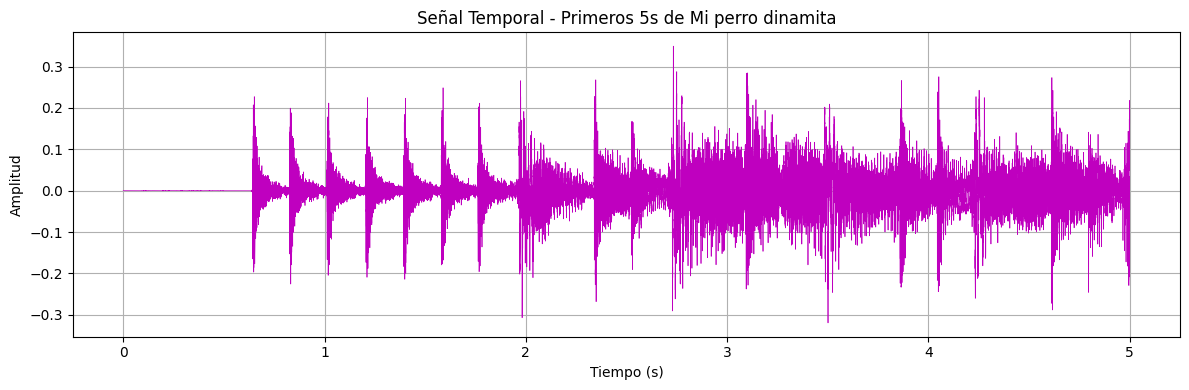

Reproduciendo los primeros 5 segundos de Mi perro dinamita:


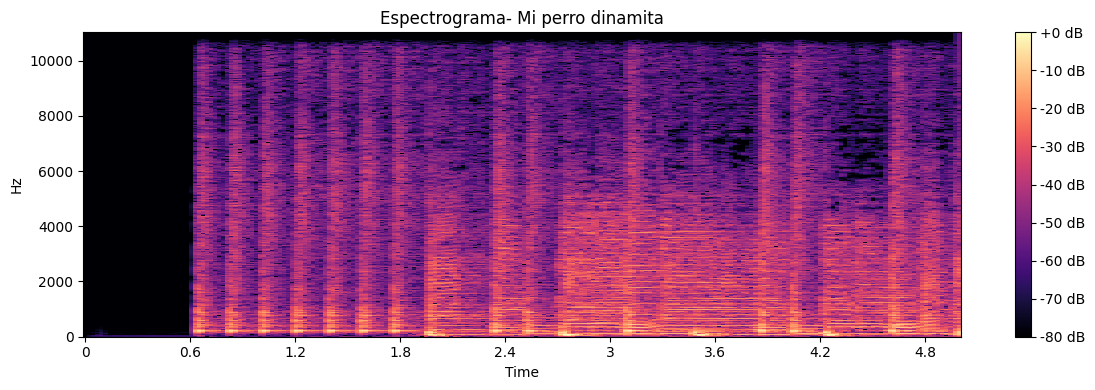

Añadidos 216 frames de entrenamiento de Mi perro dinamita.
Añadidos 216 frames de validación de Mi perro dinamita.
Añadidos 1292 frames de testeo de Mi perro dinamita.


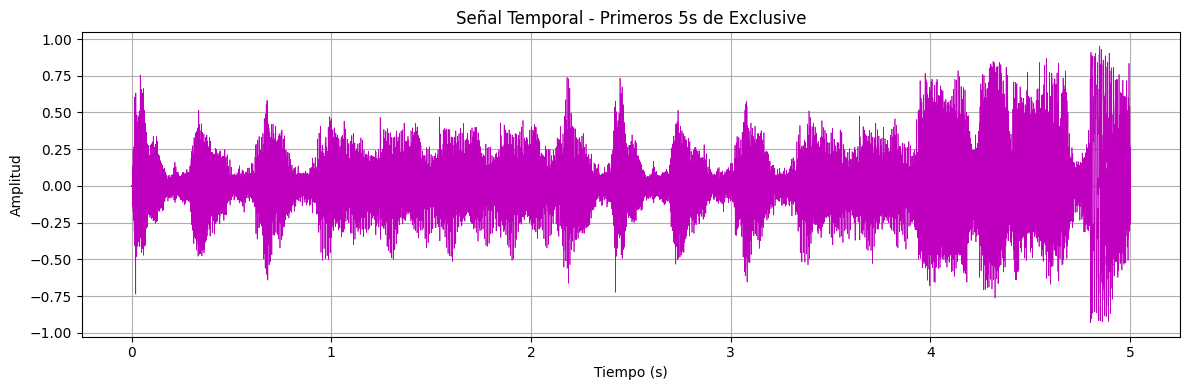

Reproduciendo los primeros 5 segundos de Exclusive:


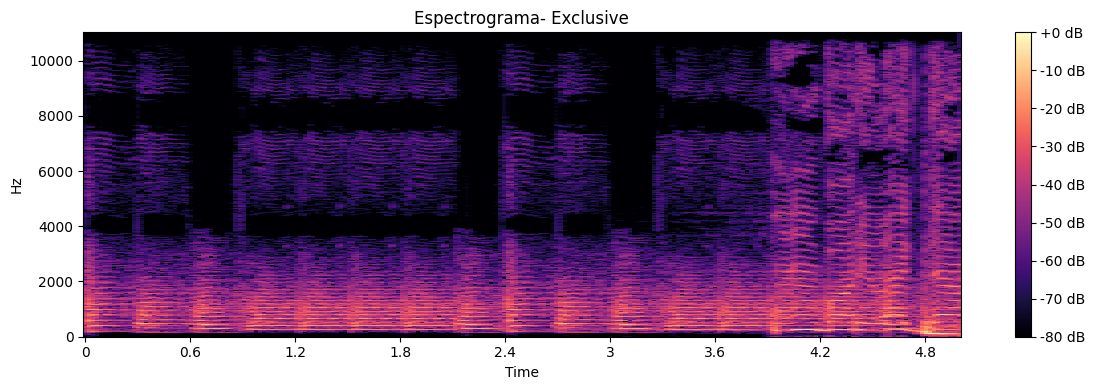

Añadidos 216 frames de entrenamiento de Exclusive.
Añadidos 216 frames de validación de Exclusive.
Añadidos 1292 frames de testeo de Exclusive.

--- Resumen de los conjuntos de datos ---
Entrenamiento:    432 frames × 1025 features
Validación:       432 frames × 1025 features
Testeo:          2584 frames × 1025 features

Distribución de clases:
Entrenamiento: {np.str_('Exclusive'): np.int64(216), np.str_('Mi perro dinamita'): np.int64(216)}
Validación:    {np.str_('Exclusive'): np.int64(216), np.str_('Mi perro dinamita'): np.int64(216)}
Testeo:        {np.str_('Exclusive'): np.int64(1292), np.str_('Mi perro dinamita'): np.int64(1292)}


In [ ]:
#Parametros STFT
N_FFT = 2048
HOP_LENGTH = N_FFT // 4  # 75% de solapamiento
window = 'hann'

# Diccionarios para almacenar los datos procesados
training_data = []
training_labels = []
validation_data = []
validation_labels = []
test_data = []
test_labels = []
duracion = 5

audio_files = {
    'Mi perro dinamita': 'mi_perro_dinamita.mp3',
    'Exclusive': 'exclusive.mp3',
}

for cancion, file_path in audio_files.items():
    y, sr = librosa.load(file_path, offset=0, duration = duracion )
    time = np.linspace(0, duracion, len(y))

    plt.figure(figsize=(12, 4))
    plt.plot(time, y,color='m', linewidth=0.5)
    plt.title(f'Señal Temporal - Primeros 5s de {cancion}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Reproducir audio
    print(f"Reproduciendo los primeros 5 segundos de {cancion}:")
    display(Audio(y, rate=sr))

    # 3. Graficar Espectrograma
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=window)
    spectrogram = np.abs(stft) # Magnitud del espectrograma
    plt.figure(figsize=(12, 4))
    #Convertir a magnitud en dB
    dB = librosa.amplitude_to_db(spectrogram, ref=np.max)

    librosa.display.specshow(dB,
                        sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Espectrograma- {cancion}')
    plt.tight_layout()
    plt.show()

    # --- Construcción de Bases de Datos ---

    # 4. Base de datos de entrenamiento (primeros 5 segundos)
    stft_train = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window='hann')
    spectrogram_train = np.abs(stft_train)

    # Transponer para tener frames como filas
    for i in range(spectrogram_train.shape[1]):
        training_data.append(spectrogram_train[:, i])
        training_labels.append(cancion)
    print(f"Añadidos {spectrogram_train.shape[1]} frames de entrenamiento de {cancion}.")


    # 5. Base de datos de validación (5 segundos a partir de los 30 segundos)
    try:
        y_val, sr_val = librosa.load(file_path, offset=30, duration=5)
        stft_val = librosa.stft(y_val, n_fft=N_FFT, hop_length=HOP_LENGTH, window='hann')
        spectrogram_val = np.abs(stft_val)

        for i in range(spectrogram_val.shape[1]):
            validation_data.append(spectrogram_val[:, i])
            validation_labels.append(cancion)
        print(f"Añadidos {spectrogram_val.shape[1]} frames de validación de {cancion}.")
    except Exception as e:
        print(f"No se pudieron cargar los datos de validación para {cancion} (offset 30s): {e}")


    # 6. Base de datos de testeo (30 segundos a partir del minuto)
    try:
      y_test, sr_test = librosa.load(file_path, offset=60, duration=30)
      stft_test = librosa.stft(y_test, n_fft=N_FFT, hop_length=HOP_LENGTH, window='hann')
      spectrogram_test = np.abs(stft_test)

      for i in range(spectrogram_test.shape[1]):
          test_data.append(spectrogram_test[:, i])
          test_labels.append(cancion)
      print(f"Añadidos {spectrogram_test.shape[1]} frames de testeo de {cancion}.")
    except Exception as e:
        print(f"No se pudieron cargar los datos de testeo para {cancion} (offset 60s): {e}")

# Convertir las listas a arrays de NumPy
training_data = np.array(training_data)
training_labels = np.array(training_labels)
validation_data = np.array(validation_data)
validation_labels = np.array(validation_labels)
test_data = np.array(test_data)
test_labels = np.array(test_labels)

print("\n--- Resumen de los conjuntos de datos ---")
print(f"Entrenamiento:  {training_data.shape[0]:5d} frames × {training_data.shape[1]:4d} features")
print(f"Validación:     {validation_data.shape[0]:5d} frames × {validation_data.shape[1]:4d} features")
print(f"Testeo:         {test_data.shape[0]:5d} frames × {test_data.shape[1]:4d} features")

# Verificar distribución de clases
print("\nDistribución de clases:")
print("Entrenamiento:", dict(zip(*np.unique(training_labels, return_counts=True))))
print("Validación:   ", dict(zip(*np.unique(validation_labels, return_counts=True))))
print("Testeo:       ", dict(zip(*np.unique(test_labels, return_counts=True))))

## Aprendizaje supervisado

En el **aprendizaje supervisado** un algoritmo aprende a mapear una entrada a una salida basandose en pares de datos de entrada y salida previamente etiquetados. El objetivo es que el modelo aprenda una función que, dada una nueva entrada, pueda predecir la salida de forma correcta.
Este proceso implica una fase de entrenamiento, donde el modelo ajusta sus parámetros utilizando los datos etiquetados, una fase de evaluación, donde se optimizan los hiperpárametro, y una fase de evaluación final en el conjunto de test .

Previo al entrenamiento, se preparan los datos para entrar al modelo supervisado, se codifica las etiquetas de clase de manera que sean valores númericos enteros mediante un *LabelEncoder*, permitiendo que el algoritmo de clasificación lo pueda procesar. Luego se estandarizo las caracteristicas espectrales mediante *StandardScaler*, que transforma cada variable para tener medi cero y varianza unitaria.

Finalmente, se utiliza el conjunto de validación para seleccionar los mejores hiperpárametros de cada modelo, entranando multiples configuraciones y eligiendo la que tiene mejor desempeño. Una vez optimizado, el modelo se evalúa en el conjunto de test.





In [ ]:
# 1. Codificación de Etiquetas
label_encoder = LabelEncoder()
all_labels = np.concatenate((training_labels, validation_labels, test_labels))
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(training_labels)
y_val_encoded = label_encoder.transform(validation_labels)
y_test_encoded = label_encoder.transform(test_labels)

# 2. Escalado de Características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(training_data)
X_val_scaled = scaler.transform(validation_data)
X_test_scaled = scaler.transform(test_data)



### Regresión logistica

Para la clasificación de los frames de audio, se utilizo el modelo de Regresión Logistica, un algoritmo de aprendizaje supervisado que, es empleado para problemas de clasificación. Este modelo calcula la probabilidad de que una muestra pertenezca a una clase particular mediante la función sigmoide, aprendiendo los coeficientes que mejor separan las clases.

Luego del preprocesamiento, se identifico y selecciono el mejor hiperparametro, el cual controla la regularización del modelo. Se evaluaron seis valores candidatos, en los cuales los resultados mostraron que a medida que aumenta C, el *accuracy* en validación empeoraba progresivamente, desde aprox 85% hasta 64%, esto indica *overfitting*.

El modelo final, entrenado con C = 0.001, fue evaluado en el conjunto de test obteniendo un *accuracy* de 85.4%, y para el *test accuracy* se obtuvo un 84.7%, como vemos hay una diferencia minima por lo que podemos decir que el modelo generaliza bastante bien. Otra cosa para tener en cuenta, es que este es uno de los modelos mas simples, por lo cual es considerable que el modelo pueda distinguir correctamente entre las dos canciones más del 85.4% de los frames.

Se eligieron los valores de C, de manera que esten en escala logaritmica, porque el efecto del parametro C sobre el comportamiento del modelo es exponencial. Y el rango elegido abarca cuatro órdenes de magnitud, lo cual es apropiado para la mayoría de problemas de clasificación. Valores menores que 0.001 implicaría regularización extremadamente fuerte que podría resultar en un *underfitting* severo, mientras que mayores de 100 podría ocasionar *overfitting*.

In [ ]:
def entrenar_rl(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    C_values = [0.001, 0.01, 0.1, 1, 10, 100]
    best_C = None
    best_val_acc = 0

    for C in C_values:
        lr = LogisticRegression(C=C, max_iter=1000, random_state=42, solver='lbfgs')
        lr.fit(X_train, y_train)
        y_val_pred = lr.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_C = C

        if verbose:
            print(f"C={C:7.3f} -> Val Accuracy: {val_acc:.4f}")

    # Entrenar modelo final
    lr_final = LogisticRegression(C=best_C, max_iter=1000, random_state=42, solver='lbfgs')
    lr_final.fit(X_train, y_train)

    y_pred_test = lr_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejor C: {best_C}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return test_acc



acc_rl =entrenar_rl(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)

C=  0.001 -> Val Accuracy: 0.8472
C=  0.010 -> Val Accuracy: 0.8032
C=  0.100 -> Val Accuracy: 0.7963
C=  1.000 -> Val Accuracy: 0.7940
C= 10.000 -> Val Accuracy: 0.6435
C=100.000 -> Val Accuracy: 0.6389

✓ Mejor C: 0.001
📊 TEST ACCURACY: 0.8545 (85.45%)


### LDA - Análisis discriminante lineal

LDA es un método de clasificación supervisada que busca encontrar las combinaciones lineales de caracteristicas que mejor separan las clases. Modela la distribución de probabilidad de cada clase asumiendo que todas comparten la misma matriz de covarianza.

Para determinar la mejor configuración, se evaluaron tres algoritmos de resolución, *svd* que es la descomposición en valores singulares, *lsqr* que es minimos cuadrados y *eigen* que es la descomposición en valores propios.  Cada solver emplea un método matemático diferente para calcular las direcciones discriminantes.

*svd* alcanzo un accuracy de aprox 50.5%, *lsqr* obtuvo 26.4%, mientras que *eigen* fallo debido a que la matriz de covarinza presenta inestabilidad númerica. Por lo que se eligio el solver *svd* como la configuración óptima por su mejor rendimiento en validación.

El modelo final, obtuvo un accuracy del 51.35%, muy inferior al alcanzado por la regresión logistica. El bajo rendimiento de LDA en este problema puede atribuirse a varias razones, como el hecho de que LDA asume que las clases siguen distribuciones gaussianas con matrices de covarianza idénticas.




In [ ]:
def entrenar_lda(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    solvers = ['svd', 'lsqr', 'eigen']
    best_solver = None
    best_val_acc = 0

    for solver in solvers:
        try:
            lda = LinearDiscriminantAnalysis(solver=solver)
            lda.fit(X_train, y_train)
            y_val_pred = lda.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_solver = solver

            if verbose:
                print(f"Solver={solver:8s} -> Val Accuracy: {val_acc:.4f}")
        except Exception as e:
            if verbose:
                print(f"Solver={solver:8s} -> Error: {str(e)[:40]}")

    # Entrenar modelo final
    lda_final = LinearDiscriminantAnalysis(solver=best_solver)
    lda_final.fit(X_train, y_train)

    y_pred_test = lda_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejor solver: {best_solver}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return  test_acc

acc_lda= entrenar_lda(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)

Solver=svd      -> Val Accuracy: 0.5046
Solver=lsqr     -> Val Accuracy: 0.2639
Solver=eigen    -> Error: The leading minor of order 431 of B is n

✓ Mejor solver: svd
📊 TEST ACCURACY: 0.5135 (51.35%)


### QDA

El analisis discriminante cuadrático es una extensión del LDA, pero en este caso QDA permite que cada clase tenga su propia matriz de covarianza, resultando en fronteras de decisión cuadráticas en vez de lineales.

Se evaluaron cinco valores para el parámetro de regularización, la elección de estos valores abarca desde la ausencia de regularización en absoluto (0.0) hasta lo que se puede considerar una regularización moderada-fuerte (0.5) con incrementos progresivos.

El rendimiento mejoro sustancialmente con el incremento de la regularización, pero se presentaron problemas dado que el número de caracteristicas excede o se aproxima al número de muestras por clase, esto resulta en matrices de covarianza mal condiiconeas con determinantes cercanos a cero.

El modelo final, entrenado con reg_param = 0.5, en el conjunto de test, obtuvo un accuracy de 85.7%, muy similar al modelo de regresión logistica, y mucho mejor que LDA.

In [ ]:
def entrenar_qda(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    reg_params = [0.0, 0.01, 0.1, 0.3, 0.5]
    best_reg = None
    best_val_acc = 0

    for reg in reg_params:
        try:
            qda = QuadraticDiscriminantAnalysis(reg_param=reg)
            qda.fit(X_train, y_train)
            y_val_pred = qda.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_reg = reg

            if verbose:
                print(f"reg_param={reg:5.2f} -> Val Accuracy: {val_acc:.4f}")
        except Exception as e:
            if verbose:
                print(f"reg_param={reg:5.2f} -> Error: {str(e)[:40]}")

    # Entrenar modelo final
    qda_final = QuadraticDiscriminantAnalysis(reg_param=best_reg)
    qda_final.fit(X_train, y_train)

    y_pred_test = qda_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejor reg_param: {best_reg}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return  test_acc


acc_qda= entrenar_qda(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)

reg_param= 0.00 -> Val Accuracy: 0.4097


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


reg_param= 0.01 -> Val Accuracy: 0.6597
reg_param= 0.10 -> Val Accuracy: 0.8542


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


reg_param= 0.30 -> Val Accuracy: 0.8588
reg_param= 0.50 -> Val Accuracy: 0.8727


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(



✓ Mejor reg_param: 0.5
📊 TEST ACCURACY: 0.8576 (85.76%)


### KNN

El algoritmo K-Nearest Neighbors es un método de clasificación no paramétrico   que memoriza todos los ejemplos y realiza predicciones en tiempo de inferencia.
Para clasificar una nueva muestra, KNN identifica los k ejemplos de entrenamiento más cercanos y asigna la clase mayoritaria entre esos vecinos.

Para determinar el valor óptimo del hiperparametro k, se evaluaron 9 valores, todos impares lo cual previene situaciones de ''empate'' en clasificación binaria, empezando en k = 1, que es el vecino más cercano y el valor mínimo posible, este presenta alto riesgo de *overfitting*. Luego le siguen valores pequeños, medianos y valores grandes pero no tanto, dado que la predicción podría estar influenciada por muestras muy distantes que aportan poco valor discriminativo.

Los resultados de rendimiento en el conjunto de validación mostraron una tendencia decreciente, por lo que la elección del mejor hiperparametro fue la del vecino más cercano, k=1, donde se obtuvo un accuracy del 91% aprox, hasta ahora el mejor rendimiento. Esto puede decir que frames de la misma canción son significativamente más similares entre sí que frames de la otra canción, esto tiene sentido ya que vimos cierto patron repetitivo claro en lo que es el grafico temporal, el espectograma y en el mismo audio de voz.


In [ ]:
def entrenar_knn(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
    best_k = None
    best_val_acc = 0

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_val_pred = knn.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_k = k

        if verbose:
            print(f"k={k:3d} -> Val Accuracy: {val_acc:.4f}")

    # Entrenar modelo final
    knn_final = KNeighborsClassifier(n_neighbors=best_k)
    knn_final.fit(X_train, y_train)

    y_pred_test = knn_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejor k: {best_k}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return  test_acc

acc_knn = entrenar_knn(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)


k=  1 -> Val Accuracy: 0.8843
k=  3 -> Val Accuracy: 0.8657
k=  5 -> Val Accuracy: 0.8611
k=  7 -> Val Accuracy: 0.8565
k=  9 -> Val Accuracy: 0.8380
k= 11 -> Val Accuracy: 0.8148
k= 15 -> Val Accuracy: 0.8148
k= 21 -> Val Accuracy: 0.8056
k= 31 -> Val Accuracy: 0.7894

✓ Mejor k: 1
📊 TEST ACCURACY: 0.9106 (91.06%)


## SVM

Support Vector Machine con kernel RBF es un algoritmo de clasificación supervisada que busca encontrar el hiperplano óptimo de separación entre clases en un espacio transformado de mayor dimensión.
El rendimiento de SVM depende del hiperparametro de regularización (C) y el parámetro del kernel RBF (γ).

La elección de los valores de C responde a la misma lógica empleada en la regresión logística. El parametro gamma controla el ''alcance'' de la influencia de cada muestra de entrenamiento, valores bajos de gamma (ej: 0.001) significan que cada punto de entrenamiento tiene influencia amplia, resultando en fronteras de decisión suaves que consideran muestras lejanas; valores altos de gamma (ej: 0.1) hacen que solo las muestras muy cercanas tengan influencia, produciendo fronteras irregulares y complejas que se ajustan estrechamente a los datos de entrenamiento.

Se observó que 'scale' y 'auto' consistentemente produjeron los mejores resultados para cada valor de C, validando la estrategia de usar parámetros adaptativos en lugar de valores fijos arbitrarios. El rendimiento mejoró monotonamente al aumentar C desde 0.1 (78.24% con gamma='scale') hasta C=10 (85.19% con gamma='scale'), donde se alcanzó el óptimo, manteniéndose estable en C=100 (también 85.19%). Esto indica que el modelo se beneficia de menor regularización hasta cierto punto, después del cual aumentar C no aporta mejora adicional.


La configuración óptima identificada fue C=10 con gamma='scale' (o equivalentemente 'auto'), alcanzando 85.19% de accuracy en validación. Es notable que C=100 con los mismos valores de gamma produjo exactamente el mismo resultado (85.19%), sugiriendo que a partir de C=10 el modelo ya alcanzó su capacidad máxima de separación y reducir aún más la regularización no aporta beneficio.

El modelo final, entrenado con C=10 y gamma='scale', fue evaluado en el conjunto de test obteniendo un accuracy de 86.26%.

In [ ]:
def entrenar_svm(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    C_values = [0.1, 1, 10, 100]
    gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1]

    best_params = None
    best_val_acc = 0

    for C in C_values:
        for gamma in gamma_values:
            svm = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
            svm.fit(X_train, y_train)
            y_val_pred = svm.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = (C, gamma)

            if verbose:
                gamma_str = str(gamma) if isinstance(gamma, str) else f"{gamma:.3f}"
                print(f"C={C:6.1f}, gamma={gamma_str:8s} -> Val Acc: {val_acc:.4f}")

    # Entrenar modelo final
    svm_final = SVC(C=best_params[0], gamma=best_params[1], kernel='rbf', random_state=42)
    svm_final.fit(X_train, y_train)

    y_pred_test = svm_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejores parámetros: C={best_params[0]}, gamma={best_params[1]}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")


    return test_acc

acc_svm = entrenar_svm(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)


C=   0.1, gamma=scale    -> Val Acc: 0.7824
C=   0.1, gamma=auto     -> Val Acc: 0.7824
C=   0.1, gamma=0.001    -> Val Acc: 0.7778
C=   0.1, gamma=0.010    -> Val Acc: 0.4699
C=   0.1, gamma=0.100    -> Val Acc: 0.4792
C=   1.0, gamma=scale    -> Val Acc: 0.8472
C=   1.0, gamma=auto     -> Val Acc: 0.8472
C=   1.0, gamma=0.001    -> Val Acc: 0.8472
C=   1.0, gamma=0.010    -> Val Acc: 0.5301
C=   1.0, gamma=0.100    -> Val Acc: 0.4769
C=  10.0, gamma=scale    -> Val Acc: 0.8519
C=  10.0, gamma=auto     -> Val Acc: 0.8519
C=  10.0, gamma=0.001    -> Val Acc: 0.8495
C=  10.0, gamma=0.010    -> Val Acc: 0.5347
C=  10.0, gamma=0.100    -> Val Acc: 0.4769
C= 100.0, gamma=scale    -> Val Acc: 0.8519
C= 100.0, gamma=auto     -> Val Acc: 0.8519
C= 100.0, gamma=0.001    -> Val Acc: 0.8495
C= 100.0, gamma=0.010    -> Val Acc: 0.5347
C= 100.0, gamma=0.100    -> Val Acc: 0.4769

✓ Mejores parámetros: C=10, gamma=scale
📊 TEST ACCURACY: 0.8626 (86.26%)


### Arbol de decisión

Los Árboles de Decisión son modelos de aprendizaje supervisado que realizan clasificación mediante una estructura jerárquica de reglas de decisión basadas en las características de entrada. El algoritmo construye el árbol dividiendo recursivamente el espacio de características: en cada nodo interno se evalúa una condición sobre una variable dirigiendo las muestras hacia las ramas izquierda o derecha según el resultado, hasta alcanzar nodos hoja que asignan una clase final.

 Se evaluaron los dos criterios estándar disponibles: 'gini' (índice de impureza de Gini) y 'entropy' (ganancia de información basada en entropía de Shannon). Esta decisión de limitar la búsqueda a un solo hiperparámetro responde a la necesidad de simplificar la exploración inicial y comprender el comportamiento base del algoritmo sin restricciones artificiales de complejidad.

Los resultados revelaron una diferencia significativa y sorprendente entre ambos criterios. Con 'gini', el árbol alcanzó apenas 63.19% de accuracy en validación. En marcado contraste, el criterio 'entropy' logró 73.15% de accuracy en validación, una mejora sustancial de casi 10 puntos porcentuales (+9.96 puntos). Esta diferencia notable indica que, para este problema específico de clasificación espectral, la ganancia de información basada en entropía identifica divisiones más efectivas que el índice de Gini, posiblemente porque entropy penaliza más fuertemente la impureza y favorece divisiones que reducen la incertidumbre de manera más agresiva.

El modelo final, entrenado con criterion='entropy', fue evaluado en el conjunto de test obteniendo un accuracy de 77.32%.


In [ ]:
def entrenar_tree(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True):

    criterion_values = ['gini', 'entropy']

    best_params = None
    best_val_acc = 0

    for criterion in criterion_values:
            tree = DecisionTreeClassifier(
                criterion=criterion,
                random_state=42
            )
            tree.fit(X_train, y_train)
            y_val_pred = tree.predict(X_val)
            val_acc = accuracy_score(y_val, y_val_pred)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = criterion

            if verbose:  # Solo mostrar los más relevantes
                  print(f"criterion={criterion:8s}, -> "
                      f"Val Acc: {val_acc:.4f}")

    # Entrenar modelo final
    tree_final = DecisionTreeClassifier(
        criterion= best_params,
        random_state=42
    )
    tree_final.fit(X_train, y_train)

    y_pred_test = tree_final.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    if verbose:
        print(f"\n✓ Mejores parámetros: ",f"  criterion: {best_params}")
        print(f"📊 TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

    return test_acc

acc_tree = entrenar_tree(X_train_scaled, y_train_encoded, X_val_scaled, y_val_encoded, X_test_scaled, y_test_encoded, verbose=True)

criterion=gini    , -> Val Acc: 0.6319
criterion=entropy , -> Val Acc: 0.7315

✓ Mejores parámetros:    criterion: entropy
📊 TEST ACCURACY: 0.7732 (77.32%)


## PCA

El análisis de componentes principales es el método lineal más utilizado en reducción de dimensión. PCA emplea la teoría de subespacios para proyectar ortogonalmente las muestras de datos dentro de un *manifold* de menor dimensión.

In [ ]:
# 2. Aplicar PCA a 30 Componentes
N_COMPONENTS = 30
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)


# Combinar train+val para entrenamiento final con PCA
X_train_val_pca = np.vstack((X_train_pca, X_val_pca))
y_train_val_encoded = np.concatenate((y_train_encoded, y_val_encoded))

print(f"Dimensiones originales: {X_train_scaled.shape[1]} -> Dimensiones con PCA: {X_train_pca.shape[1]}")

Dimensiones originales: 1025 -> Dimensiones con PCA: 30


In [ ]:
rl_pca = entrenar_rl(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)
lda_pca = entrenar_lda(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)
qda_pca = entrenar_qda(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)
knn_pca = entrenar_knn(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)
svm_pca = entrenar_svm(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)
tree_pca = entrenar_tree(X_train_pca, y_train_encoded, X_val_pca, y_val_encoded, X_test_pca, y_test_encoded, verbose=False)

models_and_params = {
    "Regresión Logística": rl_pca,
    "LDA": lda_pca,
    "QDA":qda_pca,
    "KNN": knn_pca,
    "SVM (kernel RBF)": svm_pca,
    "Árboles de Decisión": tree_pca
}

original_results = {
    "Regresión Logística": acc_rl,
    "LDA": acc_lda,
    "QDA": acc_qda,
    "KNN": acc_knn,
    "SVM (kernel RBF)": acc_svm,
    "Árboles de Decisión": acc_tree
}


### Comparación del rendimiento de los modelos

La comparación de los resultados de test muestra que la aplicación de PCA mejoró el rendimiento de todos los métodos evaluados, aunque en distinta medida. PCA reduce la dimensionalidad original de 1025 caracteristicas espectrales a 30 componentes ortogonales.

La Regresión Logística pasó de un 85.45% a un 85.76%, la diferencia no es tanta, dado que este modelo ya maneja alta dimensionalidad mediante regularización.

En contraste, LDA mostro la mejor mejora, de un rendimiento del 51.35% a uno de 73.53%, esto se explica por las limitaciones de LDA con la alta dimensionalidad. El hecho de que LDA pase de ser el peor método a alcanzar rendimiento razonable valida que su fracaso original no era conceptual sino de inestabilidad numérica por dimensionalidad excesiva.

QDA inicialmente con 85.76% con PCA alcanzo un rendimiento del 94.04%, convirtiendose en uno de los mejores modelos tras aplicar PCA. Esta ganancia significativa se debe a que QDA, al estimar matrices de covarianza separadas para cada clase,  con 1025 dimensiones, QDA intentaba estimar 2 matrices de covarianza de 1025×1025 ≈ 2 millones de parámetros totales, generando matrices singulares que solo pudieron manejarse mediante regularización fuerte (reg_param=0.5). Con PCA reduciendo a 30 dimensiones, QDA solo necesita estimar 2 matrices de 30×30 ≈ 1,800 parámetros, proporción manejable que permite capturar las diferencias de covarianza entre clases.

KNN no presenta una mejora significativa, paso de 91.06% a 91.95%, al proyectar a 30 dimensiones preservando la máxima varianza, permitiendo que k=1 identifique vecinos verdaderamente similares en lugar de arbitrariamente cercanos.

Luego en los métodos no lineales, como SVM con kernel RBF hubo una mejora de 86.26% a 96.67% y en Arbol de decisión se obtuvo de 77.32% a 90.79%, una mejora significativamente mayor a los anteriores. Para SVM, se explica porque el kernel RBF calcula similitud basada en distancia euclidiana, sufriendo los mismos problemas que KNN en el caso de alta dimensionalidad, al tener una dimensión de 30, la busqueda de hiperparametros se vuelve más estable y el entrenamiento converge más rapidamente, permitiendo encontrar configuraciones óptimas.

Luego, en el caso de los Arboles de Decisión con 30 componentes decorrelacionados, cada división tiene mayor probabilidad de basarse en direcciones verdaderamente discriminativas.

In [ ]:
# --- Comparación de Resultados ---
print("\n--- Comparación de Accuracy de Testeo (Original vs. PCA) ---")
comparison_df = pd.DataFrame({
    'Modelo': list(original_results.keys()),
    'Accuracy Original': list(original_results.values()),
    'Accuracy con PCA': [models_and_params.get(k, np.nan) for k in original_results.keys()]
})
comparison_df['Diferencia'] = comparison_df['Accuracy con PCA'] - comparison_df['Accuracy Original']
print(comparison_df.to_string(float_format="%.4f"))



--- Comparación de Accuracy de Testeo (Original vs. PCA) ---
                Modelo  Accuracy Original  Accuracy con PCA  Diferencia
0  Regresión Logística             0.8545            0.8576      0.0031
1                  LDA             0.5135            0.7353      0.2217
2                  QDA             0.8576            0.9404      0.0828
3                  KNN             0.9106            0.9195      0.0089
4     SVM (kernel RBF)             0.8626            0.9667      0.1041
5  Árboles de Decisión             0.7732            0.9079      0.1347
